Luxury Customer Behavior Analysis

This project analyzes customer purchasing behavior to identify high-value segments, revenue concentration, and key drivers of customer value. 

Key focus areas: 
- Revenue distribution and concentration
- Customer segmentation
- Purchase frequency and average order value

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("default")

df = pd.read_excel("online_retail_II.xlsx")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


Data Loading & Cleaning

The dataset was cleaned to ensure accurate analysis. This included: 
- Standardizing column names
- Removing missing customer IDs
- Filtering out invalid transactions (negative or zero values)
- Creating a revenue metric

In [4]:
df.columns = (
    df.columns
    .str.strip()
    .str.replace(r"\s+", "_", regex=True)
    .str.lower()
)

df = df.rename(columns={
    "customerid": "customer_id",
    "invoicedate": "invoice_date"
})

In [5]:
df = df.dropna(subset=["customer_id"])
df = df[df["quantity"] > 0]
df = df[df["price"] > 0]

In [6]:
df["revenue"] = df["quantity"] * df["price"]
df["invoice_date"] = pd.to_datetime(df["invoice_date"])

In [7]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 407664 entries, 0 to 525460
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   invoice       407664 non-null  object        
 1   stockcode     407664 non-null  object        
 2   description   407664 non-null  object        
 3   quantity      407664 non-null  int64         
 4   invoice_date  407664 non-null  datetime64[ns]
 5   price         407664 non-null  float64       
 6   customer_id   407664 non-null  float64       
 7   country       407664 non-null  object        
 8   revenue       407664 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 31.1+ MB


Customer-Level Aggregation

Transaction-level data was aggregated to the customer level to analyze total revenue, purchase frequency, and average order value per customer.

In [9]:
# Total revenue by customer
customer_revenue = (
    df.groupby("customer_id")["revenue"]
    .sum()
    .reset_index()
    .sort_values(by="revenue", ascending=False)
)

customer_revenue.head(10)

,customer_id,revenue
4183,18102.0,349164.35
1637,14646.0,248396.50
1269,14156.0,196566.74
1840,14911.0,152147.57
939,13694.0,131443.19
3744,17511.0,84541.17
1951,15061.0,83284.38
3128,16684.0,80489.21
3177,16754.0,65500.07
4065,17949.0,60117.60


In [10]:
customer_revenue.describe()

,customer_id,revenue
count,4312.000000,4312.000000
mean,15349.290353,2048.238236
std,1701.200176,8914.481280
min,12346.000000,2.950000
25%,13882.500000,307.987500
50%,15350.500000,706.020000
75%,16834.250000,1723.142500
max,18287.000000,349164.350000


In [12]:
# Top 10% threshold
threshold = customer_revenue["revenue"].quantile(0.90)

threshold

3800.2250000000017

In [13]:
vip_customers = customer_revenue[customer_revenue["revenue"] >= threshold]

len(vip_customers)

432

In [14]:
# Total revenue
total_revenue = customer_revenue["revenue"].sum()

# VIP revenue
vip_revenue = vip_customers["revenue"].sum()

# Percentage contribution
vip_percentage = vip_revenue / total_revenue

total_revenue, vip_revenue, vip_percentage

(8832003.273999998, 5288001.086, 0.5987317850715734)

The top 10% of customers (spending >$3.8K) account for 59.87% of total revenue, indicating a highly concentrated revenue base.

Customer Segmentation

Customers were segmented based on total revenue to analyze behavioral differences across value tiers.

In [17]:
# Create segments using quartiles
customer_revenue["segment"] = pd.qcut(
    customer_revenue["revenue"],
    q=4,
    labels=["Low Value", "Lower-Mid", "Upper-Mid", "High Value"]
)

customer_revenue.head()

,customer_id,revenue,segment
4183,18102.0,349164.35,High Value
1637,14646.0,248396.50,High Value
1269,14156.0,196566.74,High Value
1840,14911.0,152147.57,High Value
939,13694.0,131443.19,High Value


In [18]:
customer_revenue.groupby("segment", observed=False)["revenue"].agg(["count", "sum", "mean"])

,count,sum,mean
segment,,,
Low Value,1078,192573.080,178.639221
Lower-Mid,1078,513414.153,476.265448
Upper-Mid,1078,1220622.590,1132.302959
High Value,1078,6905393.451,6405.745316


In [19]:
# Number of transactions per customer
customer_orders = df.groupby("customer_id")["invoice"].nunique().reset_index()
customer_orders = customer_orders.rename(columns={"invoice": "num_orders"})

customer_orders.head()

,customer_id,num_orders
0,12346.0,11
1,12347.0,2
2,12348.0,1
3,12349.0,3
4,12351.0,1


In [20]:
customer_data = customer_revenue.merge(customer_orders, on="customer_id")

In [21]:
customer_data.groupby("segment", observed=False)["num_orders"].mean()

segment
Low Value      1.229128
Lower-Mid      2.006494
Upper-Mid      3.768089
High Value    10.819109
Name: num_orders, dtype: float64

Higher-value customers demonstrate significantly higher purchase frequency, reinforcing their role as key drivers of repeat revenue.

In [23]:
# Revenue per order
df["order_value"] = df["revenue"]

In [24]:
customer_aov = df.groupby("customer_id")["revenue"].sum() / df.groupby("customer_id")["invoice"].nunique()
customer_aov = customer_aov.reset_index(name="avg_order_value")

In [25]:
customer_data = customer_data.merge(customer_aov, on="customer_id")

In [26]:
customer_data.groupby("segment", observed=False)["avg_order_value"].mean()

segment
Low Value     157.804653
Lower-Mid     294.332855
Upper-Mid     390.097456
High Value    671.055544
Name: avg_order_value, dtype: float64

Key Insights & Visualizations

The following visualizations highlight revenue concentration and behavioral differences across customer segments.

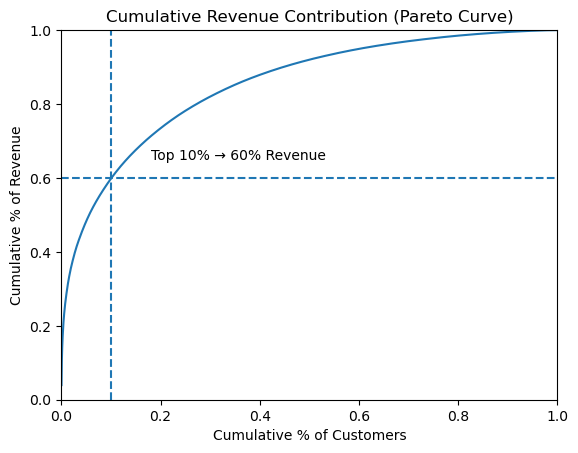

In [28]:
# Revenue Distribution


# Sort customers by revenue (descending)
customer_sorted = customer_revenue.sort_values(by="revenue", ascending=False)

# Create cumulative metrics
customer_sorted["cum_revenue"] = customer_sorted["revenue"].cumsum()
customer_sorted["cum_revenue_pct"] = customer_sorted["cum_revenue"] / customer_sorted["revenue"].sum()

customer_sorted["cum_customers"] = range(1, len(customer_sorted) + 1)
customer_sorted["cum_customers_pct"] = customer_sorted["cum_customers"] / len(customer_sorted)

# Plot
plt.plot(customer_sorted["cum_customers_pct"], customer_sorted["cum_revenue_pct"])

plt.axhline(0.60, linestyle="--")  # 60% revenue line
plt.axvline(0.10, linestyle="--")  # 10% customers line

plt.text(0.18, 0.65, "Top 10% → 60% Revenue", ha='left')

plt.xlim(0, 1)
plt.ylim(0, 1)

plt.xlabel("Cumulative % of Customers")
plt.ylabel("Cumulative % of Revenue")
plt.title("Cumulative Revenue Contribution (Pareto Curve)")

plt.show()

The Pareto curve illustrates a highly skewed revenue distribution, where the top ~10% of customers account for nearly 60% of total revenue.

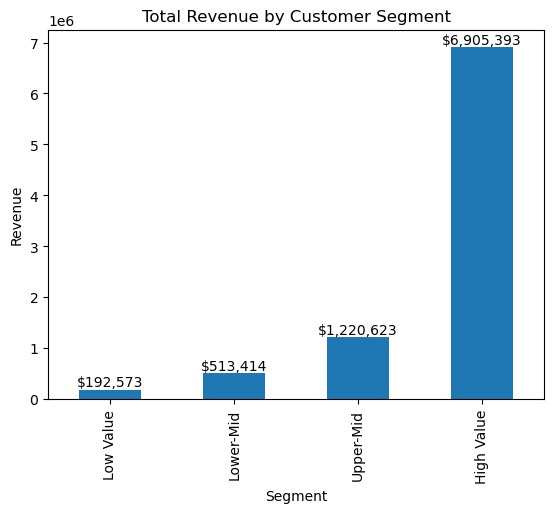

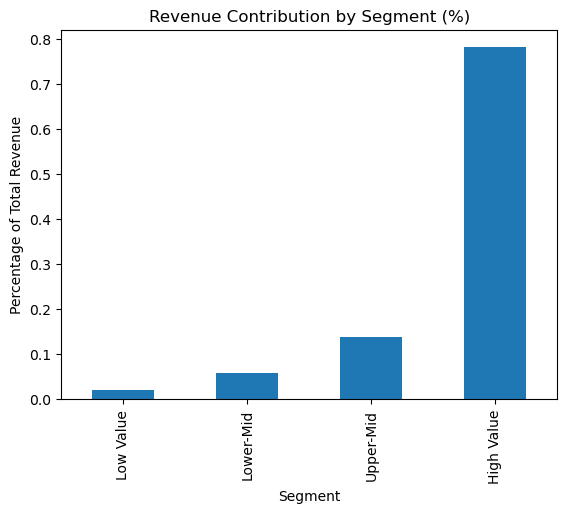

In [30]:
# Revenue by Segment

segment_summary = customer_revenue.groupby("segment", observed=False)["revenue"].sum()
ax = segment_summary.plot(kind="bar")

for i, v in enumerate(segment_summary):
    ax.text(i, v, f"${v:,.0f}", ha='center', va='bottom')

plt.title("Total Revenue by Customer Segment")
plt.ylabel("Revenue")
plt.xlabel("Segment")
plt.show()

(segment_summary / segment_summary.sum()).plot(kind="bar")

plt.title("Revenue Contribution by Segment (%)")
plt.ylabel("Percentage of Total Revenue")
plt.xlabel("Segment")
plt.show()

Despite equal customer distribution across segments, the highest-value segment contributes the majority of total revenue, reinforcing the presence of significant revenue concentration. 

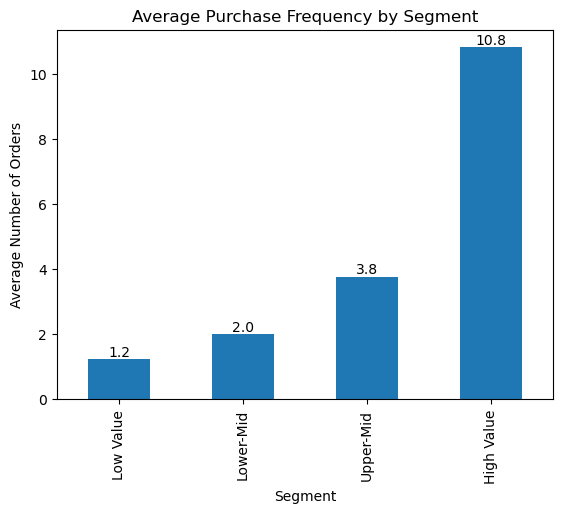

In [32]:
# Purchase Frequency by Segment

freq = customer_data.groupby("segment", observed=False)["num_orders"].mean()

ax = freq.plot(kind="bar")

for i, v in enumerate(freq):
    ax.text(i, v, f"{v:.1f}", ha='center', va='bottom')

plt.title("Average Purchase Frequency by Segment")
plt.ylabel("Average Number of Orders")
plt.xlabel("Segment")

plt.show()

Purchase frequency increases significantly across segments, with high-value customers placing nearly 9x more orders than low-value customers.

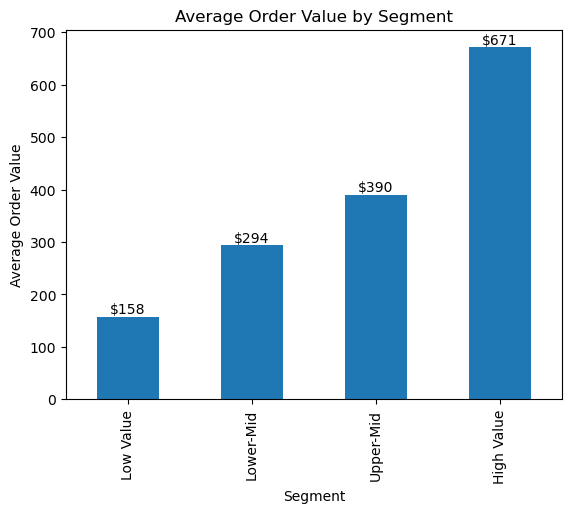

In [34]:
# Average Order Value by Segment

aov = customer_data.groupby("segment", observed=False)["avg_order_value"].mean()

ax = aov.plot(kind="bar")

for i, v in enumerate(aov):
    ax.text(i, v, f"${v:.0f}", ha='center', va='bottom')

plt.title("Average Order Value by Segment")
plt.ylabel("Average Order Value")
plt.xlabel("Segment")

plt.show()

Average order value also rises across segments, indicating that higher-value customers not only purchase more frequently but also spend more per transaction.

Key Findings

- Revenue is highly concentrated among a small subset of customers
- The top ~10% of customers account for ~60% of total revenue
- High-value customers purchase more frequently and spend more per transaction
- Customer value is driven by both engagement (frequency) and spending behavior (AOV)

Business Implications

- Prioritize retention of high-value customers
- Invest in improving the first customer experience to drive repeat purchases
- Use targeted strategies to increase frequency and spend among lower-value segments